# 🌎 Movilidad urbana y economía en Latinoamérica | 2024

Este proyecto analiza la relación entre **movilidad urbana** y **variables económicas** en 15 ciudades latinoamericanas durante 2024.

El dataset final integra indicadores de tráfico provenientes del proyecto original con variables económicas y demográficas. El objetivo de esta versión de portafolio es presentar de forma clara el análisis final a partir del archivo limpio y consolidado.

## 🎯 Pregunta de análisis

**¿Existe una relación clara entre los niveles de congestión urbana y los indicadores económicos de las ciudades analizadas?**

> **Nota:** el análisis es exploratorio y correlacional. Las relaciones observadas no implican causalidad.

## 👀 Resumen del proyecto

- **Rol:** Analista de Datos
- **Herramienta principal:** Python
- **Periodo:** 2024
- **Cobertura:** 15 ciudades latinoamericanas
- **Habilidades:** Pandas, limpieza y validación, agregación, integración de datos, análisis exploratorio, correlaciones y visualización
- **Fuentes del proyecto original:** TomTom Traffic Index y OECD Cities
- **Entregable:** Jupyter Notebook + CSV limpio

## 1. Carga y validación del dataset final

El proyecto original incluyó limpieza, estandarización de nombres, conversión de tipos, filtrado a 2024, agregación de registros de tráfico por ciudad y una unión de tipo **inner** entre movilidad y economía.

Como el notebook original no se conservó completo, esta versión reconstruida parte del **CSV final ya integrado**, sin inventar las tablas fuente que no están disponibles.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data_path = Path("ladb_mobility_economy_2024_clean.csv")
if not data_path.exists():
    data_path = Path("/mnt/data/ladb_mobility_economy_2024_clean.csv")

df = pd.read_csv(data_path)

print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
df.head()

Filas: 15
Columnas: 14


,city,year,country,jams_delay,traffic_index_live,jams_length_in_kms,jams_count,mins_delay,travel_time_live_per_10kms_mins,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment,population_m,population
0,belo-horizonte,2024,BRA,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,11124.0,9.5,6.1,6100000.0
1,bogota,2024,COL,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,11442.0,10.0,11.3,11300000.0
2,brasilia,2024,BRA,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,16251.0,7.8,4.8,4800000.0
3,buenos-aires,2024,ARG,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,18117.0,7.2,15.4,15400000.0
4,curitiba,2024,BRA,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,12381.0,8.2,3.7,3700000.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   city                                 15 non-null     object 
 1   year                                 15 non-null     int64  
 2   country                              15 non-null     object 
 3   jams_delay                           15 non-null     float64
 4   traffic_index_live                   15 non-null     float64
 5   jams_length_in_kms                   15 non-null     float64
 6   jams_count                           15 non-null     float64
 7   mins_delay                           15 non-null     float64
 8   travel_time_live_per_10kms_mins      15 non-null     float64
 9   travel_time_historic_per_10kms_mins  15 non-null     float64
 10  city_gdp_capita                      15 non-null     float64
 11  unemployment                      

In [3]:
print("Valores faltantes por columna:")
display(df.isna().sum().to_frame("nulos"))

print("\nDuplicados:", df.duplicated().sum())
print("Años disponibles:", sorted(df["year"].unique()))

Valores faltantes por columna:


,nulos
city,0
year,0
country,0
jams_delay,0
traffic_index_live,0
jams_length_in_kms,0
jams_count,0
mins_delay,0
travel_time_live_per_10kms_mins,0
travel_time_historic_per_10kms_mins,0



Duplicados: 0
Años disponibles: [np.int64(2024)]


### Variables principales

**Movilidad**
- `jams_delay`: indicador agregado de retraso asociado a congestión.
- `traffic_index_live`: índice de tráfico.
- `jams_length_in_kms`: longitud agregada de congestiones.
- `jams_count`: cantidad agregada de congestionamientos.
- `mins_delay`: minutos de retraso.
- `travel_time_live_per_10kms_mins`: tiempo de viaje actual por 10 km.
- `travel_time_historic_per_10kms_mins`: tiempo histórico por 10 km.

**Economía y población**
- `city_gdp_capita`: PIB per cápita de la ciudad.
- `unemployment`: desempleo.
- `population_m` / `population`: población.

## 2. Exploración descriptiva

In [4]:
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,15.0,2024.00,0.00,2024.00,2024.00,2024.00,2024.00,2024.00
jams_delay,15.0,629.52,783.06,50.20,107.17,263.05,841.08,2833.06
traffic_index_live,15.0,22.10,7.48,11.26,17.35,20.16,26.02,37.61
jams_length_in_kms,15.0,87.86,105.16,6.37,17.61,44.04,105.30,389.24
jams_count,15.0,144.32,168.16,14.16,30.25,68.81,183.27,594.97
mins_delay,15.0,0.62,0.62,0.07,0.17,0.39,0.88,1.86
travel_time_live_per_10kms_mins,15.0,19.03,3.27,13.34,17.08,18.30,20.45,25.67
travel_time_historic_per_10kms_mins,15.0,18.42,2.81,13.15,16.75,17.82,19.81,24.17
city_gdp_capita,15.0,13253.60,5686.21,2277.00,10156.50,12381.00,15477.00,26176.00
unemployment,15.0,8.69,2.26,3.20,7.80,8.50,9.75,12.40


### Ciudades con mayor `jams_delay`

In [5]:
ranking_delay = (
    df[["city", "country", "jams_delay", "traffic_index_live",
        "travel_time_live_per_10kms_mins", "city_gdp_capita"]]
    .sort_values("jams_delay", ascending=False)
    .reset_index(drop=True)
)

ranking_delay.head(10)

,city,country,jams_delay,traffic_index_live,travel_time_live_per_10kms_mins,city_gdp_capita
0,mexico-city,MEX,2833.057892,34.218190,21.809092,21111.0
1,sao-paulo,BRA,1729.189270,26.877932,20.801836,14703.0
2,bogota,COL,1141.552364,37.614273,24.992185,11442.0
3,lima,PER,1052.292789,31.031277,25.674261,13472.0
4,santiago,CHL,629.865318,20.155352,17.031310,2277.0
5,buenos-aires,ARG,571.089593,17.756012,17.907916,18117.0
6,rio-de-janeiro,BRA,466.064706,25.162963,17.137320,13349.0
7,belo-horizonte,BRA,263.047879,19.428946,18.304538,11124.0
8,curitiba,BRA,183.469274,14.954545,17.258700,12381.0
9,porto-alegre,BRA,139.382830,17.687254,16.166684,11801.0


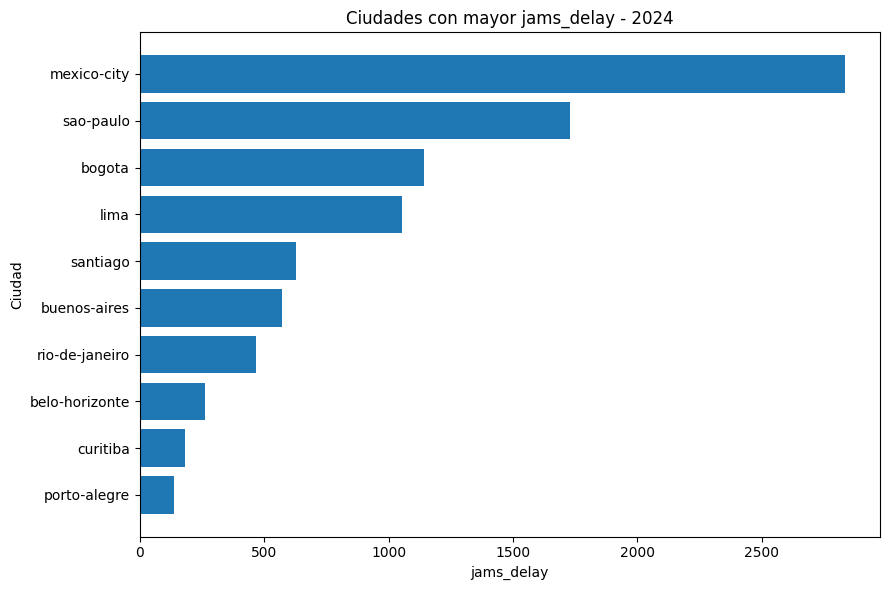

In [6]:
top = ranking_delay.head(10).sort_values("jams_delay")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top["city"], top["jams_delay"])
ax.set_title("Ciudades con mayor jams_delay - 2024")
ax.set_xlabel("jams_delay")
ax.set_ylabel("Ciudad")
plt.tight_layout()
plt.show()

**Lectura:** dentro del dataset final, **Ciudad de México** presenta el mayor `jams_delay`, seguida por **São Paulo, Bogotá y Lima**. Esto muestra diferencias importantes de congestión entre las ciudades analizadas.

### Tiempo de viaje por 10 km

In [7]:
travel = (
    df[["city", "travel_time_live_per_10kms_mins"]]
    .sort_values("travel_time_live_per_10kms_mins", ascending=False)
)

travel

,city,travel_time_live_per_10kms_mins
6,lima,25.674261
1,bogota,24.992185
7,mexico-city,21.809092
14,sao-paulo,20.801836
10,recife,20.101569
5,fortaleza,19.267171
8,montevideo,18.892342
0,belo-horizonte,18.304538
3,buenos-aires,17.907916
4,curitiba,17.258700


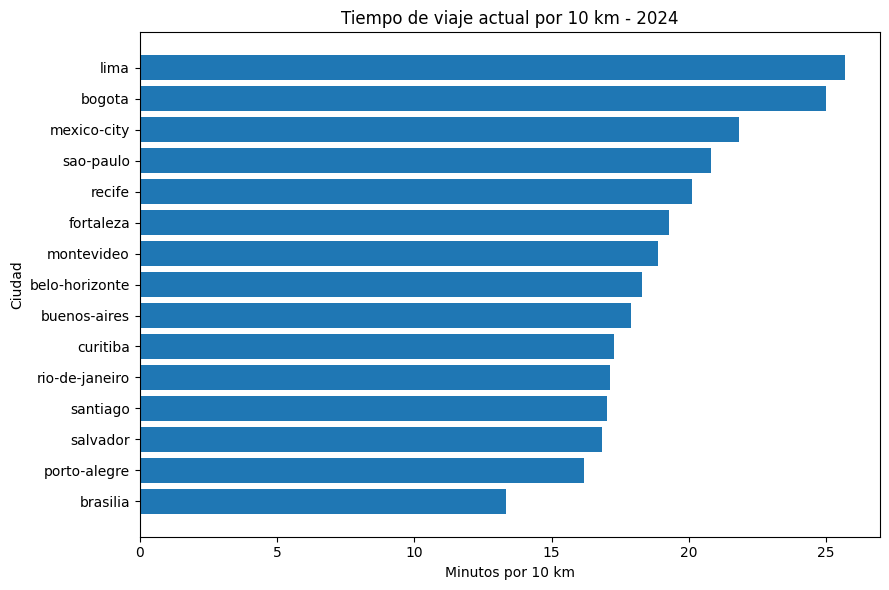

In [8]:
plot_travel = travel.sort_values("travel_time_live_per_10kms_mins")

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(plot_travel["city"], plot_travel["travel_time_live_per_10kms_mins"])
ax.set_title("Tiempo de viaje actual por 10 km - 2024")
ax.set_xlabel("Minutos por 10 km")
ax.set_ylabel("Ciudad")
plt.tight_layout()
plt.show()

En el tiempo de viaje por 10 km destacan **Lima** y **Bogotá**, ambas por encima de 24 minutos en el dataset. Esta métrica permite comparar la experiencia de viaje sin depender únicamente del tamaño de la ciudad.

## 3. Relación entre movilidad y economía

### Matriz de correlación

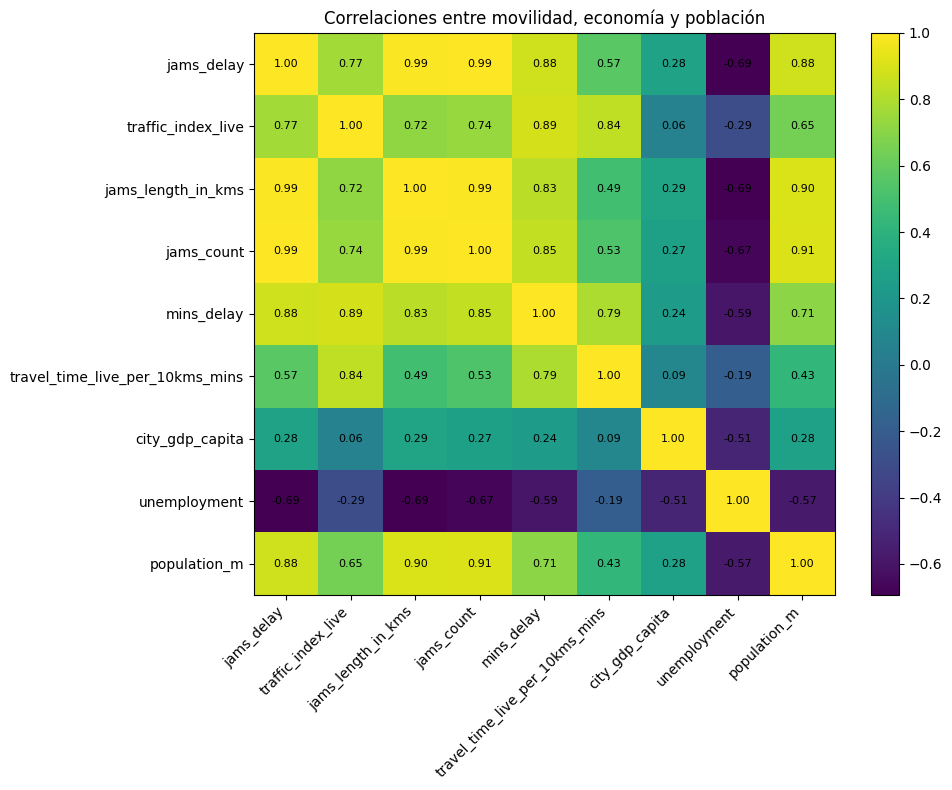

In [9]:
analysis_cols = [
    "jams_delay",
    "traffic_index_live",
    "jams_length_in_kms",
    "jams_count",
    "mins_delay",
    "travel_time_live_per_10kms_mins",
    "city_gdp_capita",
    "unemployment",
    "population_m"
]

corr = df[analysis_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, aspect="auto")

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=8)

ax.set_title("Correlaciones entre movilidad, economía y población")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

### PIB per cápita vs. congestión

In [10]:
pearson_gdp_delay = df["city_gdp_capita"].corr(df["jams_delay"])
pearson_gdp_traffic = df["city_gdp_capita"].corr(df["traffic_index_live"])
pearson_gdp_travel = df["city_gdp_capita"].corr(df["travel_time_live_per_10kms_mins"])

print(f"PIB per cápita vs jams_delay: {pearson_gdp_delay:.3f}")
print(f"PIB per cápita vs traffic_index_live: {pearson_gdp_traffic:.3f}")
print(f"PIB per cápita vs tiempo de viaje por 10 km: {pearson_gdp_travel:.3f}")

PIB per cápita vs jams_delay: 0.283
PIB per cápita vs traffic_index_live: 0.056
PIB per cápita vs tiempo de viaje por 10 km: 0.092


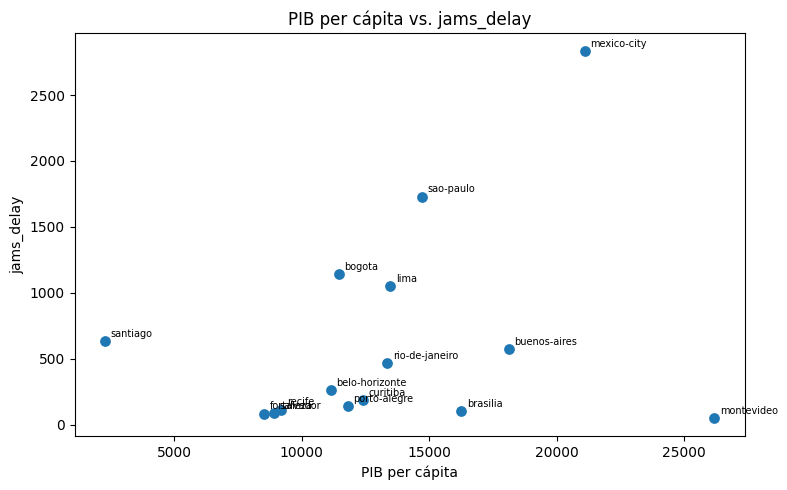

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["city_gdp_capita"], df["jams_delay"], s=45)

for _, row in df.iterrows():
    ax.annotate(row["city"], (row["city_gdp_capita"], row["jams_delay"]),
                xytext=(4, 3), textcoords="offset points", fontsize=7)

ax.set_title("PIB per cápita vs. jams_delay")
ax.set_xlabel("PIB per cápita")
ax.set_ylabel("jams_delay")
plt.tight_layout()
plt.show()

La relación entre **PIB per cápita y `jams_delay` es positiva pero débil** (aprox. **0.28**). Con `traffic_index_live` y con el tiempo de viaje por 10 km la relación es todavía menor.

Por lo tanto, en esta muestra **no se observa una relación clara entre mayor PIB per cápita y mayor congestión**. La movilidad probablemente está relacionada con otros factores que no están incluidos en este dataset.

### Población y congestión

Población vs jams_delay: 0.879


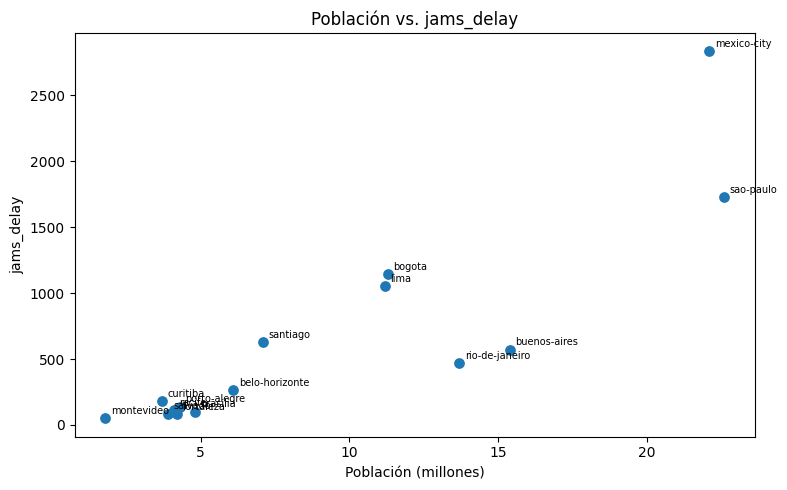

In [12]:
population_corr = df["population_m"].corr(df["jams_delay"])
print(f"Población vs jams_delay: {population_corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["population_m"], df["jams_delay"], s=45)

for _, row in df.iterrows():
    ax.annotate(row["city"], (row["population_m"], row["jams_delay"]),
                xytext=(4, 3), textcoords="offset points", fontsize=7)

ax.set_title("Población vs. jams_delay")
ax.set_xlabel("Población (millones)")
ax.set_ylabel("jams_delay")
plt.tight_layout()
plt.show()

La población también presenta una asociación positiva pero débil con `jams_delay` en estas 15 ciudades. El tamaño urbano por sí solo no explica completamente las diferencias observadas.

### Desempleo y movilidad

In [13]:
unemployment_corr = (
    df[analysis_cols]
    .corr()["unemployment"]
    .drop("unemployment")
    .sort_values()
)

unemployment_corr.to_frame("correlacion_con_desempleo").round(3)

,correlacion_con_desempleo
jams_length_in_kms,-0.693
jams_delay,-0.687
jams_count,-0.666
mins_delay,-0.593
population_m,-0.572
city_gdp_capita,-0.514
traffic_index_live,-0.294
travel_time_live_per_10kms_mins,-0.186


En esta muestra aparecen correlaciones negativas entre desempleo y varias métricas de congestión. Sin embargo, con solo **15 ciudades** y sin controlar por otros factores económicos o urbanos, este resultado debe interpretarse con cautela y no como una relación causal.

## 4. Hallazgos principales

### Hallazgo 1 — La congestión está concentrada en algunas grandes ciudades

Ciudad de México, São Paulo, Bogotá y Lima presentan los valores más altos de `jams_delay` dentro del dataset final. Esto sugiere que el problema de congestión no se distribuye de manera uniforme entre las ciudades analizadas.

### Hallazgo 2 — El PIB per cápita no explica claramente la congestión

La correlación entre `city_gdp_capita` y `jams_delay` es de aproximadamente **0.28**, mientras que con `traffic_index_live` es cercana a **0.06**. En esta muestra no hay evidencia de una relación fuerte entre productividad económica y tráfico.

### Hallazgo 3 — Diferentes métricas de movilidad cuentan historias distintas

Lima y Bogotá destacan por el tiempo de viaje por 10 km, mientras que Ciudad de México y São Paulo sobresalen en `jams_delay`. Por ello, conviene analizar varias métricas de movilidad y no depender de un único indicador.

## 5. Recomendaciones

- Utilizar **varias métricas de movilidad** para comparar ciudades: congestión acumulada, índice de tráfico y tiempo por 10 km.
- Evitar asumir que las ciudades con mayor PIB per cápita tendrán necesariamente mayor o menor congestión.
- Incorporar en futuros análisis variables como infraestructura vial, transporte público, densidad urbana y uso del automóvil.
- Ampliar el número de ciudades y años para evaluar si los patrones se mantienen en el tiempo.

## 6. Limitaciones

- El dataset final contiene únicamente **15 ciudades** y corresponde a **2024**.
- El archivo consolidado conserva los valores de las fuentes del proyecto original; esta reconstrucción no modifica valores atípicos o inesperados sin evidencia adicional.
- Las correlaciones describen asociaciones, no causalidad.
- No se cuenta en esta reconstrucción con los dos archivos fuente originales, por lo que el análisis comienza desde el CSV final integrado.

## 📌 Conclusión

El análisis muestra diferencias importantes en movilidad entre las ciudades latinoamericanas estudiadas, pero **no identifica una relación fuerte y directa entre PIB per cápita y congestión**.

Los resultados sugieren que el desempeño de la movilidad urbana depende de múltiples factores y que las variables económicas por sí solas no son suficientes para explicarlo. Para una evaluación más completa sería necesario incorporar información sobre infraestructura, transporte público, densidad y evolución temporal.